<a href="https://colab.research.google.com/github/chittimella-srinikitha/Data-Analytics-Projects-UM-/blob/youtube_data_analytics/Youtube_Data_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Objective:** Analyze YouTube channel video data to uncover patterns that drive Views, Watch Time, CTR, and Engagement, and provide actionable recommendations for content strategy, upload timing, and audience retention.

**Business Use:**
* Identify which content formats perform best
* Optimize upload schedules
* Understand engagement patterns
* Improve audience targeting
* Plan content calendars using data-driven insights

In [ ]:
import pandas as pd

df = pd.read_csv("/content/youtube_channel_real_performance_analytics.csv")
print("Rows, columns:", df.shape)
display(df.head())

Rows, columns: (364, 70)


,ID,Video Duration,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201.0,2016-06-02 00:00:00,0,2,6,2016,Thursday,0.024,723.0,...,0.0,0.0,40.38,81.0,23531.0,533.1636,51.0,0.561,41118.0,27.66
1,1,391.0,2016-06-10 00:00:00,8,10,6,2016,Friday,0.056,727.0,...,0.0,0.0,39.85,156.0,11478.0,500.5628,33.0,0.648,41627.0,5.85
2,2,133.0,2016-06-14 00:00:00,4,14,6,2016,Tuesday,0.014,76.0,...,0.0,0.0,30.88,41.0,6153.0,70.7287,8.0,0.089,38713.0,7.07
3,3,14.0,2016-06-29 00:00:00,15,29,6,2016,Wednesday,0.004,18.0,...,0.0,0.0,103.05,14.0,4398.0,17.6251,2.0,0.017,35245.0,5.60
4,4,45.0,2016-07-01 00:00:00,2,1,7,2016,Friday,0.000,0.0,...,0.0,0.0,55.70,25.0,14659.0,104.3341,28.0,0.000,46218.0,8.62


**Basic Cleaning**

In [ ]:
# Convert publish time
time_cols = [c for c in df.columns if "publish" in c.lower()]
if time_cols:
    df["publish_time"] = pd.to_datetime(df[time_cols[0]], errors="coerce")
else:
    df["publish_time"] = pd.NaT

# Numeric cleanup
for col in df.columns:
    if df[col].dtype == object:
        try:
            df[col] = df[col].str.replace(",", "").astype(float)
        except:
            pass

df = df.fillna(0)

**Feature Engineering**

In [ ]:
df.columns

Index(['ID', 'Video Duration', 'Video Publish Time', 'Days Since Publish',
       'Day', 'Month', 'Year', 'Day of Week', 'Revenue per 1000 Views (USD)',
       'Monetized Playbacks (Estimate)', 'Playback-Based CPM (USD)',
       'CPM (USD)', 'Ad Impressions', 'Estimated AdSense Revenue (USD)',
       'DoubleClick Revenue (USD)', 'YouTube Ads Revenue (USD)',
       'Watch Page Ads Revenue (USD)', 'YouTube Premium (USD)',
       'Transaction Revenue (USD)', 'Transactions',
       'Revenue from Transactions (USD)', 'Reactions', 'Chat Messages Count',
       'Reminders Set', 'Stream Hours', 'Remix Views', 'Remix Count',
       'Subscribers from Posts', 'New Comments', 'Shares', 'Like Rate (%)',
       'Dislikes', 'Likes', 'Unsubscribes', 'New Subscribers',
       'Returned Items (USD)', 'Unconfirmed Commissions (USD)',
       'Approved Commissions (USD)', 'Orders', 'Total Sales Volume (USD)',
       'End Screen Click-Through Rate (%)', 'End Screen Impressions',
       'End Screen Clicks', 

In [ ]:
import numpy as np

df["engagement"] = df["Likes"] + df["New Comments"] + df["Shares"]
df["engagement_rate"] = np.where(df["Views"]>0, df["engagement"]/df["Views"], 0)
df["ctr"] = df["Video Thumbnail CTR (%)"]
df["publish_hour"] = df["publish_time"].dt.hour.fillna(-1)
df["publish_dayname"] = df["publish_time"].dt.day_name()
df["publish_month"] = df["publish_time"].dt.to_period("M").astype(str)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

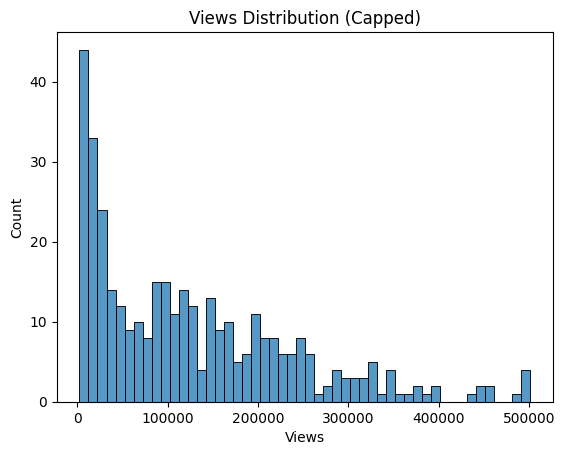

In [ ]:
# Views distribution
sns.histplot(df["Views"].clip(upper=df["Views"].quantile(0.99)), bins=50)
plt.title("Views Distribution (Capped)")
plt.show()

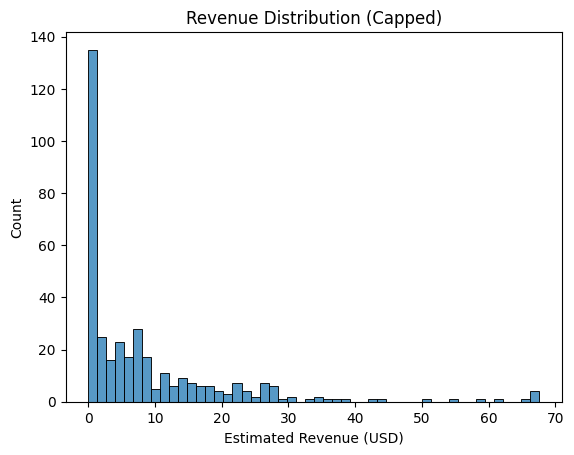

In [ ]:
# Revenue distribution
sns.histplot(df["Estimated Revenue (USD)"].clip(upper=df["Estimated Revenue (USD)"].quantile(0.99)), bins=50)
plt.title("Revenue Distribution (Capped)")
plt.show()

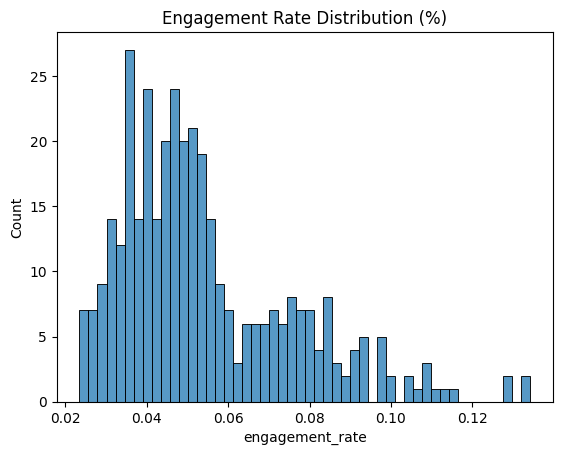

In [ ]:
# Engagement distribution
sns.histplot(df["engagement_rate"], bins=50)
plt.title("Engagement Rate Distribution (%)")
plt.show()

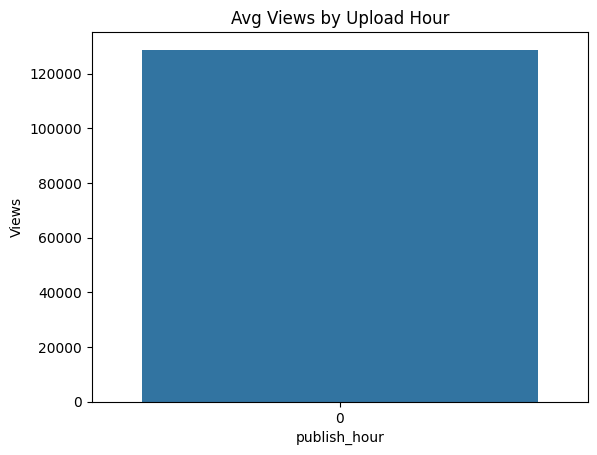

In [ ]:
import plotly.express as px

# Monthly views trend
monthly = df.groupby("publish_month")["Views"].sum().reset_index()

px.line(monthly, x="publish_month", y="Views", title="Monthly Views Trend").show()

# Upload hour performance
upload_hour = df.groupby("publish_hour")["Views"].mean().reset_index()
sns.barplot(upload_hour, x="publish_hour", y="Views")
plt.title("Avg Views by Upload Hour")
plt.show()

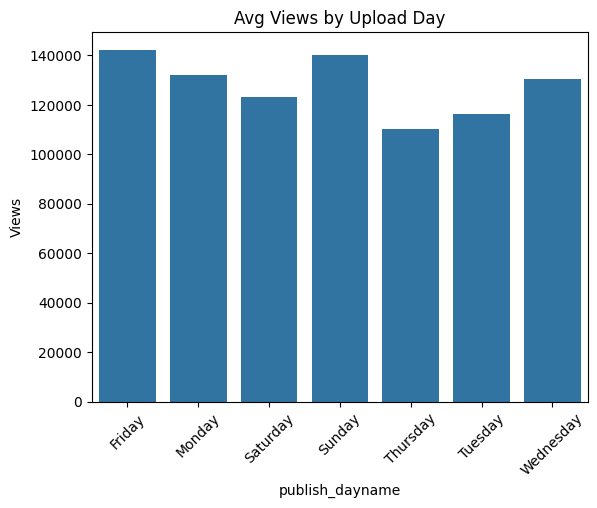

In [ ]:
# Upload weekday performance
weekday = df.groupby("publish_dayname")["Views"].mean().reset_index()
sns.barplot(weekday, x="publish_dayname", y="Views")
plt.xticks(rotation=45)
plt.title("Avg Views by Upload Day")
plt.show()

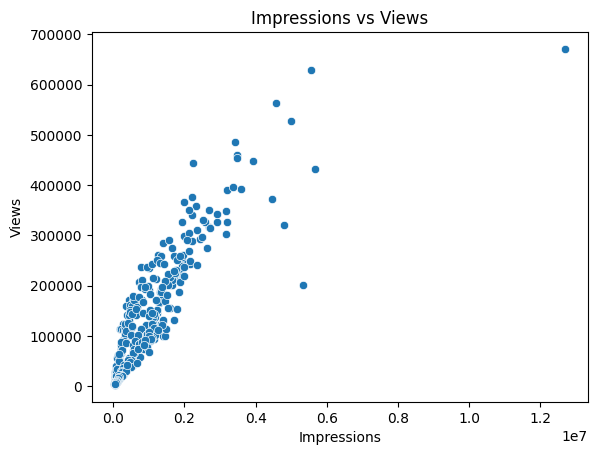

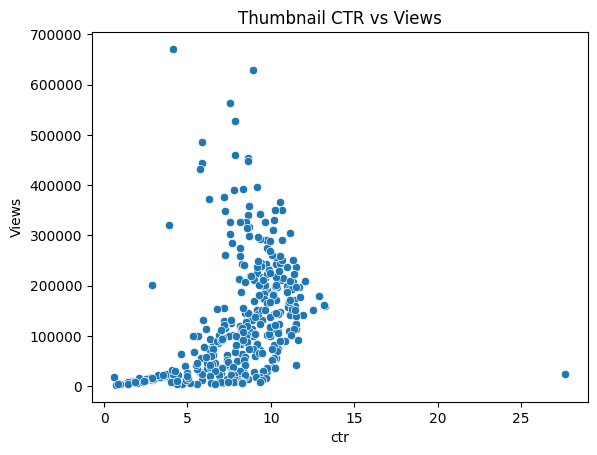

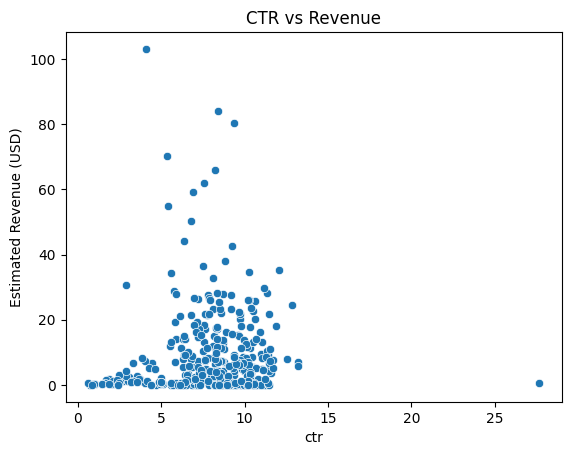

In [ ]:
sns.scatterplot(df, x="Impressions", y="Views")
plt.title("Impressions vs Views")
plt.show()

sns.scatterplot(df, x="ctr", y="Views")
plt.title("Thumbnail CTR vs Views")
plt.show()

sns.scatterplot(df, x="ctr", y="Estimated Revenue (USD)")
plt.title("CTR vs Revenue")
plt.show()